# How does heat transport shape regional climates?
**Week 5 · Tropical–polar boxes**

The surface–deep-ocean model explored fast and slow adjustment. Now we use two boxes to represent **places with different solar heating**. Each region exchanges radiation with space and energy with the other region.

**Central question:** How can a region maintain a steady temperature even when its absorbed sunlight and outgoing radiation do not balance?

All code is supplied. **Make a guess or work it out, run, then explain.** Focus on regional temperatures, transported energy, and conservation. No eigenvalue calculation or numerical-solver implementation is required. The core activity is provisionally 15–20 minutes, subject to classroom testing. The final parameter sweep is optional.

This is an idealized annual-mean climate, with fixed insolation and albedo. Its parameters are illustrative rather than fitted to observations or CMIP6. No data downloads are needed. Run all cells in order with NumPy, pandas, Matplotlib, and SciPy installed.

## Start with observations: where does Earth gain and lose energy?

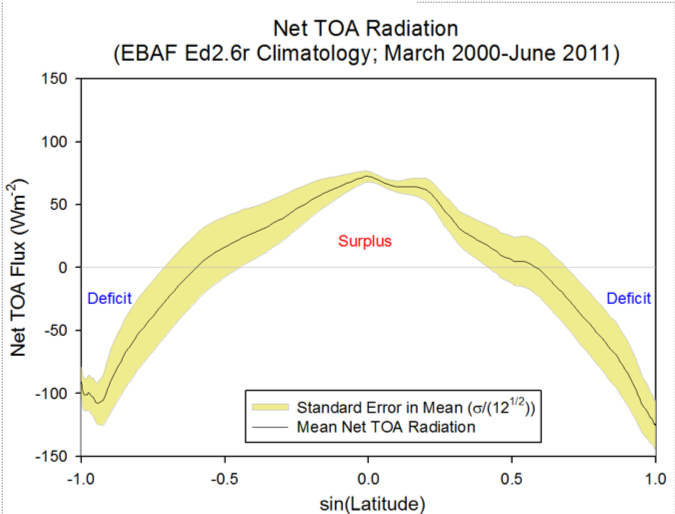

Net radiation at the top of the atmosphere (TOA) is **absorbed sunlight minus outgoing infrared radiation**, in W m⁻². Positive values mean a radiative energy gain; negative values mean a loss. This is a climatological mean, rather than a seasonal snapshot.

The horizontal axis is **sine of latitude**: −1 is the South Pole, 0 is the equator, and +1 is the North Pole. Equal intervals on this axis represent latitude bands with equal areas.

1. Where does Earth gain energy by radiation, and where does it lose energy?
2. If radiation were the only process, what would happen to temperatures in those regions?
3. What could keep the tropics from continually warming and the higher latitudes from continually cooling?

We will use two regional boxes to explore how heat transport can balance these radiative gains and losses.

*Source: [NASA CERES Science](https://ceres.larc.nasa.gov/science/), [original figure](https://ceres.larc.nasa.gov/images/NetTOARadiation.png). CERES EBAF Edition 2.6r climatology, March 2000–June 2011, as labeled in the original. The yellow band is labeled standard error in the mean.*

## 1. Two equal-area regions and their budgets

Use two regions with **the same area**: a low-latitude belt from 30°S to 30°N, and the combined higher latitudes in both hemispheres. We call these the tropical and polar boxes. The second includes midlatitudes as well as the poles.

Each region receives prescribed sunlight $I_i$ and has a fixed albedo $\mathcal{A}_i$. Its absorbed sunlight is

$$
S_i=(1-\mathcal{A}_i)I_i.
$$

These are regional averages. Outgoing infrared radiation follows a simple prescribed law:

$$
R(T_i)=R_0+B(T_i-T_0).
$$

We choose $R_0=210$ W m⁻² at $T_0=273.15$ K (0°C), and $B=2$ W m⁻² K⁻¹. Each degree of warming increases outgoing radiation by 2 W m⁻². For example, a box at 20°C emits 250 W m⁻². These are illustrative parameters representing radiation escaping to space through the atmosphere. They remain fixed during each run; the changing temperature determines the outgoing flux. With fixed absorbed sunlight, the corresponding net feedback is $\alpha=-B<0$.

$T_t$ and $T_p$ are regional temperatures, not warming anomalies. The code uses kelvin and the plots show °C.

Let the poleward heat-transfer flux be

$$
Q=\kappa(T_t-T_p),
$$

where $Q$ is in W m⁻² and $\kappa\geq0$ is in W m⁻² K⁻¹. Because the boxes have equal areas, the same flux leaves one region and enters the other:

$$
C_t\frac{dT_t}{dt}=S_t-R(T_t)-Q,
$$

$$
C_p\frac{dT_p}{dt}=S_p-R(T_p)+Q.
$$

The heat capacities are per square metre of each region. Both regions exchange radiation with space. Transport represents the combined effect of atmospheric and oceanic circulation.

**Can you figure out:** With no transport, which region will be warmer? If heat flows poleward, how does it enter each region's budget?

**Your response:**



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})
SECONDS_PER_YEAR = 365.25 * 24 * 3600
BASE = dict(I_t=400.0, I_p=260.0,
            albedo_t=0.30, albedo_p=0.30, R0=210.0, B=2.0, T0=273.15,
            Ct=2.2e8, Cp=2.2e8, initial_C=10.0)
TROPICAL, POLAR, MEAN = '#c54b26', '#2374a5', '#666666'
FIGURES = {}

display(pd.DataFrame({
    'Incoming sunlight (W/m²)': [BASE['I_t'], BASE['I_p']],
    'Albedo': [BASE['albedo_t'], BASE['albedo_p']],
    'Absorbed sunlight (W/m²)': [(1-BASE['albedo_t'])*BASE['I_t'],
                                (1-BASE['albedo_p'])*BASE['I_p']],
}, index=['Tropical belt', 'Higher latitudes']).round(3))

### Supplied numerical integration

The function integrates the two budgets from a uniform initial temperature of 10°C. We compare the resulting steady climates.

The parameter `kappa` controls transport in W m⁻² K⁻¹. The code also tracks accumulated global net radiation so we can check energy conservation. With equal-area boxes, the global mean is the simple average of the two regional values.

In [ ]:
def simulate(kappa=0.4, years=100.0, output_step=0.25,
             rtol=1e-8, atol=1e-10, **changes):
    p = {**BASE, **changes}
    if set(changes) - set(BASE):
        raise ValueError('Unknown physical parameter.')
    if not all(np.isfinite(v) for v in [kappa, years, output_step, *p.values()]):
        raise ValueError('Use finite parameter values.')
    if min(p['Ct'], p['Cp'], p['B'], years, output_step) <= 0:
        raise ValueError('Use positive capacities, B and times.')
    if kappa < 0 or min(p['I_t'], p['I_p']) < 0:
        raise ValueError('Use nonnegative conductance and sunlight.')
    if not all(0 <= p[k] <= 1 for k in ['albedo_t', 'albedo_p']):
        raise ValueError('Albedos must be between zero and one.')
    St, Sp = (1-p['albedo_t'])*p['I_t'], (1-p['albedo_p'])*p['I_p']
    initial_K = p['initial_C'] + 273.15

    def budget(t, state):
        Tt, Tp, incoming_GJ = state
        Nt = St - (p['R0'] + p['B']*(Tt-p['T0']))
        Np = Sp - (p['R0'] + p['B']*(Tp-p['T0']))
        Q = kappa*(Tt-Tp)
        return [SECONDS_PER_YEAR*(Nt-Q)/p['Ct'],
                SECONDS_PER_YEAR*(Np+Q)/p['Cp'],
                SECONDS_PER_YEAR*((Nt+Np)/2)/1e9]

    time = np.linspace(0, years, int(np.ceil(years/output_step))+1)
    sol = solve_ivp(budget, (0, years), [initial_K, initial_K, 0.0],
                    t_eval=time, rtol=rtol, atol=atol)
    if not sol.success:
        raise RuntimeError(sol.message)
    Tt, Tp, incoming_GJ = sol.y
    Nt = St - (p['R0'] + p['B']*(Tt-p['T0']))
    Np = Sp - (p['R0'] + p['B']*(Tp-p['T0']))
    Q = kappa*(Tt-Tp)
    out = pd.DataFrame(dict(year=time, Tt_K=Tt, Tp_K=Tp,
        Tt_C=Tt-273.15, Tp_C=Tp-273.15, mean_C=(Tt+Tp)/2-273.15,
        contrast_K=Tt-Tp, Q=Q, Nt=Nt, Np=Np,
        transport_t=-Q, transport_p=Q,
        storage_t=Nt-Q, storage_p=Np+Q,
        global_N=(Nt+Np)/2,
        stored_GJ=(p['Ct']*(Tt-initial_K)+p['Cp']*(Tp-initial_K))/2/1e9,
        incoming_GJ=incoming_GJ))
    out.attrs.update(St=St, Sp=Sp, params=p, kappa=kappa)
    return out

transport_values = [0.0, 0.2, 0.8]  # absent, weak, strong (W/m²/K)
runs = {k: simulate(k) for k in transport_values}

## 2. Turn on poleward transport

Keep regional sunlight, albedo, and radiation properties fixed; change only transport strength.

**Can you make a guess or figure it out?** Compared with no transport, will the tropics warm or cool at equilibrium? What about the higher latitudes? Will the two temperatures become identical for a finite transport coefficient?

**Your response:**



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True, layout='constrained')
for ax, k in zip(axes, [transport_values[0], transport_values[-1]]):
    run = runs[k]
    part = run[run.year <= 30]
    ax.plot(part.year, part.Tt_C, color=TROPICAL, label='Tropical belt', lw=2)
    ax.plot(part.year, part.Tp_C, color=POLAR, label='Higher latitudes', lw=2)
    ax.plot(part.year, part.mean_C, color=MEAN, ls='--', label='Global mean', lw=2)
    ax.set(xlabel='Years from initialization', xlim=(0, 30),
           title=f'Transport coefficient = {k:g} W/m²/K')
axes[0].set_ylabel('Regional temperature (°C)')
axes[0].legend(fontsize=9, loc='center right', bbox_to_anchor=(0.98, 0.38))
FIGURES['temperatures'] = fig
plt.show()

equilibria = pd.DataFrame({k: run.iloc[-1] for k, run in runs.items()}).T
equilibria.index.name = 'Transport coefficient (W/m²/K)'
display(equilibria[['Tt_C', 'Tp_C', 'mean_C', 'contrast_K', 'Q', 'global_N']].rename(
    columns={'Tt_C':'Tropical (°C)', 'Tp_C':'Higher latitudes (°C)', 'mean_C':'Mean (°C)',
             'contrast_K':'Contrast (K)', 'Q':'Poleward flux (W/m²)',
             'global_N':'Global net radiation (W/m²)'}).round(3))
print('Table uses year 100; we will check the local budgets before calling it equilibrium.')

## 3. How can unequal radiative budgets be steady?

For the strongest transport run, inspect the late-time budgets. Radiation is positive into the region. The signed transport contribution is negative for the tropics and positive for the higher latitudes. Their sum is the local energy-storage rate.

**Can you make a guess or figure it out?** At equilibrium, which quantities must be zero: local net radiation, heat transport, local storage rate, or global net radiation?

**Your response:**



In [ ]:
chosen = runs[transport_values[-1]]
end = chosen.iloc[-1]
budget_table = pd.DataFrame({
    'Net radiation (W/m²)': [end.Nt, end.Np],
    'Transport contribution (W/m²)': [end.transport_t, end.transport_p],
    'Storage rate (W/m²)': [end.storage_t, end.storage_p],
}, index=['Tropical belt', 'Higher latitudes'])
display(budget_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), layout='constrained')
x = np.arange(2)
for offset, (column, color) in zip([-0.26, 0, 0.26], zip(budget_table.columns, ['#7251a2', '#268b8b', '#555555'])):
    axes[0].bar(x+offset, budget_table[column], width=0.24, color=color, label=column.split(' (')[0])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set(xticks=x, xticklabels=budget_table.index, ylabel='Local flux (W/m²)',
            title='Regional steady budgets')
axes[0].legend(fontsize=8, loc='upper left', bbox_to_anchor=(0, 1.0))
extent = max(1.0, budget_table.abs().to_numpy().max())
axes[0].set_ylim(-1.4*extent, 2.0*extent)
axes[1].plot(chosen.year, chosen.stored_GJ, color='black', lw=2, label='Change in total stored energy')
axes[1].plot(chosen.year, chosen.incoming_GJ, color='#b57ab4', lw=2, ls='--', label='Accumulated net radiation')
axes[1].set(xlabel='Years from initialization', ylabel='Energy per Earth area (GJ/m²)',
            title='Global energy check', xlim=(0, 30))
axes[1].legend(fontsize=8, loc='lower right')
FIGURES['budgets'] = fig
plt.show()

print(f"Tropical export: {-end.transport_t:.3f} W/m²")
print(f"Polar import:     {end.transport_p:.3f} W/m²")
print(f"Largest remaining local storage rate at year 100: {max(abs(end.storage_t), abs(end.storage_p)):.2e} W/m²")
residual = chosen.stored_GJ - chosen.incoming_GJ
print(f"Maximum accumulated energy mismatch: {abs(residual).max():.2e} GJ/m²")

**Explain:** Why do the transport terms cancel when we add the two budgets? At equilibrium, must the radiation budget of each region be zero?

The energy check uses changes from the initial state, per unit Earth area. Since each region occupies half the planet,

$$
\Delta E=\frac{C_t(T_t-T_{t,\mathrm{initial}})+C_p(T_p-T_{p,\mathrm{initial}})}{2},
$$

$$
\Delta E=\int_0^t\frac{N_t+N_p}{2}\,dt.
$$

The code converts years to seconds to keep the energy units consistent.

**Your response:**



## 4. What changed, and what stayed the same?

Use the table to compare the absent, weak, and strong transport runs:

1. Quantify the change in the temperature contrast.
2. Did the equilibrium global mean change? Explain why this depends on our radiation assumptions.
3. Does stronger transport necessarily mean a larger temperature difference to drive it?

With the **same linear radiation law in both regions**, the mean outgoing radiation is $R_0+B(\overline{T}-T_0)$. At equilibrium it equals $(S_t+S_p)/2$. Thus the mean equilibrium temperature is fixed by the prescribed radiation, independently of transport strength.

This is a property of this model, not a universal consequence of conservation. Nonlinear radiation, different regional radiative properties, or temperature-dependent albedo can allow redistribution to change the equilibrium global mean. Our albedos remain prescribed even if a region cools below freezing; an evolving ice edge is a later model extension.

**Your response:**



### Optional experiment: sweep the transport strength

The supplied code repeats the numerical integration over a range of transport coefficients. Change the list to explore another range. All radiation parameters and areas remain fixed. The values are illustrative; this is not a calibration of actual atmospheric or oceanic transport.

**Can you make a guess or figure it out?** As the temperature contrast shrinks, must the transported power shrink too?

In [ ]:
conductances = np.linspace(0.0, 1.6, 17)  # W/m²/K
sweep = pd.DataFrame([simulate(k).iloc[-1] for k in conductances], index=conductances)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), layout='constrained')
axes[0].plot(conductances, sweep.Tt_C, color=TROPICAL, label='Tropical belt', lw=2)
axes[0].plot(conductances, sweep.Tp_C, color=POLAR, label='Higher latitudes', lw=2)
axes[0].plot(conductances, sweep.mean_C, color=MEAN, ls='--', label='Global mean', lw=2)
axes[0].set(ylabel='Equilibrium temperature (°C)', title='Stronger transport reduces the contrast')
axes[0].legend(fontsize=9)
axes[1].plot(conductances, sweep.Q, color='#268b8b', lw=2)
axes[1].set(ylabel='Poleward flux (W/m²)', title='More transfer with a smaller contrast')
for ax in axes:
    ax.set_xlabel('Transport coefficient κ (W/m²/K)')
    ax.set_xlim(conductances[0], conductances[-1])
FIGURES['transport_sweep'] = fig
plt.show()
print(f'Maximum late-time storage rate across the sweep: {sweep[["storage_t", "storage_p"]].abs().to_numpy().max():.2e} W/m²')

**Your response:**



## Closing comparison: what do the two box models teach us?

| Question | Surface–deep ocean | Tropical–polar regions |
|---|---|---|
| Why choose two boxes? | Different storage and adjustment times | Different solar heating across regions |
| Temperature variables | Warming anomalies from reference states | Actual regional temperatures |
| Direct exchange with space | Represented through the surface box | A radiation budget for each region |
| Internal transfer | Additional surface-to-deep exchange | Net poleward energy transport |
| Eventual steady state | Anomalous exchange vanishes for positive coupling | Nonzero transport can persist |

**In two sentences:** Explain how a polar region can stay at a fixed temperature while emitting more radiation than it absorbs. Then explain why that does not violate global conservation of energy.

This model parameterizes the combined effect of winds and ocean currents. It does not predict those motions, regional weather, seasons, or changes in albedo. Later we can subdivide the regions into latitude bands; that extension is outside this practical.

### Optional reading

- Brian Rose, [“Heat transport,” The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook/courseware/heat-transport/): connect regional radiation budgets with poleward transport. Focus on the energy-budget interpretation; the column-model calculations are not required here.
- McGuffie & Henderson-Sellers, *The Climate Modelling Primer*, 4th edition, Figure 3.15: a tropical–polar box-model schematic. Our area conventions and illustrative parameters are specified in this notebook rather than copied from that figure.
- Brian Rose, [“The one-dimensional energy balance model”](https://brian-rose.github.io/ClimateLaboratoryBook/courseware/one-dim-ebm/), opening section: see how the same idea becomes exchange among latitude bands. The subsequent equations are optional background for a later week.

**Your response:**

